In [26]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

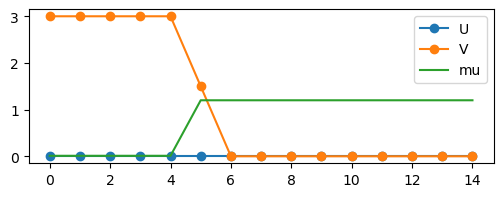

In [27]:
widthN =10
widthP =5

X, Y = widthN+widthP, 60
lattice = Lattice(X, Y)
t = 1
T=0.001

muN = 1.2 * t
muP = 0.01 * t
mu = np.zeros(lattice.X)
mu[:widthP] = muP
mu[widthP:] = muN

U = None
V_prime = None

V0 = 3 * t
V = V0 * np.ones(lattice.X)
V[widthP:] = 0
V[widthP] = V0/2

U0 = -0 * t
U = U0 * np.ones(lattice.X)
U[widthP:] = 0
U[widthP] = U0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

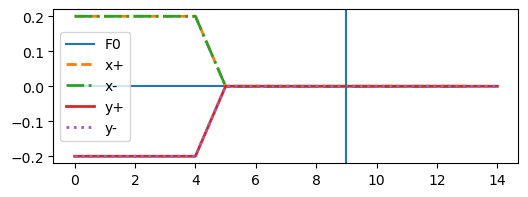

In [28]:
H = Hamiltonian(t, mu, lattice,
                U=U, V_prime=V_prime, g_s=V,
                F_init=[0.2, 0.2, -0.2, -0.2])

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.real(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.real(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [29]:
bdg_sc(H, atol=1e-5, rtol=0.01, maxiter=1000, verbose=True, temperature=T, mixing=0.2)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.023125697156030554
Relative error: 23125697156.030556
Average old: 0j
Average: (0.0029198708459804504+0j)
F_xplus:
Absolute error: 0.052329919021801195
Relative error: 8130423768.371777
Average old: (0.07142857142857142+0j)
Average: (0.08060452459122612+0j)
F_xmin:
Absolute error: 0.052329919021801154
Relative error: 8130423768.371729
Average old: (0.07142857142857142+0j)
Average: (0.08060452459122608+0j)
F_yplus:
Absolute error: 0.056705807177728065
Relative error: 25130131443.694096
Average old: (-0.06666666666666667+0j)
Average: (-0.0783968243267649+1.7892618342953994e-17j)
F_ymin:
Absolute error: 0.056705807177728065
Relative error: 25130131443.694096
Average old: (-0.06666666666666667+0j)
Average: (-0.0783968243267649-1.7892618342953994e-17j)
Fuu_xplus:
Absolute error: 2.132314578343206e-17
Relative error: 2.132314578343206e-05
Average old: 0j
Average: (1.3439432159182787e-18+0j)
Fuu_xmin:
Absolute error: 1.7874042943939847e-17
Relative error: 1.7874042943939

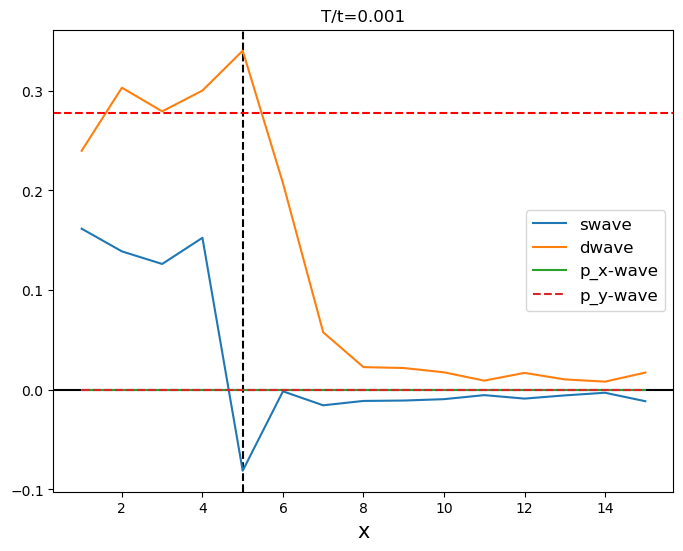

In [30]:
x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}")
axs.axhline(0, color = 'black')
axs.axvline(widthP, color='black', linestyle='--')
axs.plot(x, np.real(F.swave), label="swave")

axs.plot(x, np.real(F.dwave), label="dwave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.axhline(0.278, linestyle='--', color="red")

axs.legend(fontsize=12, loc="best")
plt.show()

In [31]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
